# ReviewLens: E-Commerce Review Sentiment Intelligence Dashboard
## Phase 2: Cleaning, Exploratory Data Analysis & VADER Sentiment Analysis

**Author:** ReviewLens Senior Data Science & NLP Architecture Team  
**Environment:** Python 3.12 | Windows 11 | JupyterLab Desktop  
**Data Mode:** `DEMO` / Deterministic Synthetic Demonstration Dataset

## 1. Project Objective

This notebook executes the end-to-end sentiment analysis pipeline on the raw customer review dataset:
1. **Data Audit:** Inspect missingness, formatting anomalies, and invalid ratings.
2. **Data Cleaning:** Strip whitespace, remove basic HTML, tokenize URLs, remove duplicates, and isolate invalid ratings.
3. **Feature Engineering:** Calculate text metrics (word count, sentence count, exclamation count) and temporal groupings.
4. **VADER Sentiment Analysis:** Calculate polarity scores (`neg`, `neu`, `pos`, `compound`), map to sentiment labels, and derive 5-tier intensity groupings.
5. **Exploratory Data Analysis:** Render 10 professional-grade visualizations in `output/charts/`.
6. **Evaluation:** Compare star ratings against VADER compound classifications to identify alignment patterns and lexicon limitations.
7. **Exported Artifacts:** Generate clean datasets, business-ready CSV tables, and an executive insight report.

## 2. Imports and Configuration

In [1]:
import sys
from pathlib import Path
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Resolve project root dynamically
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from backend.pipeline import (
    clean_review_dataset,
    apply_vader_sentiment,
    generate_summary_tables,
    generate_all_charts,
    generate_sentiment_analysis_report_md,
)
from backend.sentiment import analyze_review

# Configure consistent visual aesthetics
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'font.family': 'sans-serif', 'figure.autolayout': True})

DATA_RAW = PROJECT_ROOT / 'data' / 'raw' / 'reviews_raw.csv'
DATA_PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
OUTPUT_CHARTS_DIR = PROJECT_ROOT / 'output' / 'charts'
OUTPUT_TABLES_DIR = PROJECT_ROOT / 'output' / 'tables'
OUTPUT_REPORTS_DIR = PROJECT_ROOT / 'output' / 'reports'

for d in [DATA_PROCESSED_DIR, OUTPUT_CHARTS_DIR, OUTPUT_TABLES_DIR, OUTPUT_REPORTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('Imports and configuration initialized successfully.')

Imports and configuration initialized successfully.


## 3. Data Loading & Audit

In [2]:
df_raw = pd.read_csv(DATA_RAW)
print(f'Raw dataset loaded from {DATA_RAW}')
print(f'Shape: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns')

# Audit missing values
print('\nMissing values per column:')
display(df_raw.isnull().sum().to_frame(name='Missing Count'))

Raw dataset loaded from C:\Users\RANADEEP\Documents\reviewlens-sentiment-dashboard\data\raw\reviews_raw.csv
Shape: 212 rows x 13 columns

Missing values per column:


,Missing Count
review_id,0
product_name,0
product_category,0
source,0
source_url,0
review_title,3
review_text,1
rating,1
review_date,0
verified_purchase,0


## 4. Data Cleaning Pipeline

The cleaning pipeline executes the following rules:
1. Preserves original review text in `original_review_text`.
2. Creates `cleaned_review_text` with stripped edges and normalized whitespace.
3. Removes HTML tags safely.
4. Normalizes URL fragments to `[URL]` token.
5. Converts missing review titles to safe empty string `""`.
6. Converts `helpful_votes` to integer (defaulting missing/invalid to 0).
7. Converts `verified_purchase` to boolean and `review_date` to datetime.
8. Removes fully duplicated rows and duplicate review texts (preserving first valid record).
9. Removes empty or unusable review text rows.
10. Validates ratings: retains 1 through 5, and logs invalid records to `output/tables/invalid_rating_records.csv`.

In [3]:
df_cleaned, cleaning_summary_df, invalid_ratings_df = clean_review_dataset(df_raw)

print('--- Data Cleaning Funnel Summary ---')
display(cleaning_summary_df)

# Save cleaning summary
summary_path = OUTPUT_TABLES_DIR / 'cleaning_summary.csv'
cleaning_summary_df.to_csv(summary_path, index=False)
print(f'Saved cleaning summary to {summary_path}')

# Save invalid rating records
invalid_path = OUTPUT_TABLES_DIR / 'invalid_rating_records.csv'
invalid_ratings_df.to_csv(invalid_path, index=False)
print(f'Saved {len(invalid_ratings_df)} invalid rating records to {invalid_path}')

# Save cleaned dataset
cleaned_data_path = DATA_PROCESSED_DIR / 'reviews_cleaned.csv'
df_cleaned.to_csv(cleaned_data_path, index=False)
print(f'Saved cleaned dataset ({len(df_cleaned)} rows) to {cleaned_data_path}')

--- Data Cleaning Funnel Summary ---


,Stage,Count,Percentage
0,Raw Row Count,212,100.0%
1,Fully Duplicated Rows Removed,2,0.94%
2,Duplicate Text Rows Removed,3,1.42%
3,Empty or Invalid Text Rows Removed,2,0.94%
4,Invalid Ratings Removed,4,1.89%
5,Final Retained Row Count,201,94.81%


Saved cleaning summary to C:\Users\RANADEEP\Documents\reviewlens-sentiment-dashboard\output\tables\cleaning_summary.csv
Saved 4 invalid rating records to C:\Users\RANADEEP\Documents\reviewlens-sentiment-dashboard\output\tables\invalid_rating_records.csv
Saved cleaned dataset (201 rows) to C:\Users\RANADEEP\Documents\reviewlens-sentiment-dashboard\data\processed\reviews_cleaned.csv


## 5. Feature Engineering Summary

In [4]:
engineered_features = [
    'character_count', 'word_count', 'sentence_count', 'exclamation_count',
    'question_count', 'uppercase_ratio', 'has_url', 'has_repeated_punctuation',
    'review_year', 'review_month', 'review_quarter', 'rating_group'
]
print('Engineered Features Sample:')
display(df_cleaned[['review_id', 'rating', 'rating_group'] + engineered_features[:5]].head(5))

print('\nRating Group Distribution:')
print(df_cleaned['rating_group'].value_counts())

Engineered Features Sample:


,review_id,rating,rating_group,character_count,word_count,sentence_count,exclamation_count,question_count
0,DEMO-00001,2,Negative,172,21,3,0,0
1,DEMO-00002,4,Positive,239,32,2,0,0
2,DEMO-00003,4,Positive,207,31,3,0,0
3,DEMO-00004,4,Positive,200,26,3,0,0
4,DEMO-00005,2,Negative,200,36,3,0,0



Rating Group Distribution:
rating_group
Positive    121
Negative     48
Neutral      32
Name: count, dtype: int64


## 6. VADER Sentiment Scoring

We apply VADER (`SentimentIntensityAnalyzer`) to compute:
- `vader_neg`, `vader_neu`, `vader_pos`: component proportions.
- `compound_score`: normalized composite metric in [-1.0, 1.0].
- `sentiment_label`: standard thresholds (>= 0.05: Positive, <= -0.05: Negative, else Neutral).
- `sentiment_strength`: 5-tier intensity classification.
- `rating_sentiment_match`: boolean alignment indicator (`rating_group == sentiment_label`).
- `score_abs`: absolute compound intensity.

In [5]:
df_sentiment = apply_vader_sentiment(df_cleaned)

sentiment_data_path = DATA_PROCESSED_DIR / 'reviews_with_sentiment.csv'
df_sentiment.to_csv(sentiment_data_path, index=False)
print(f'Saved sentiment-enriched dataset ({len(df_sentiment)} rows) to {sentiment_data_path}')

print('\nSentiment Analysis Results Sample:')
display(df_sentiment[['review_id', 'rating', 'compound_score', 'sentiment_label', 'sentiment_strength', 'rating_sentiment_match']].head(8))

Saved sentiment-enriched dataset (201 rows) to C:\Users\RANADEEP\Documents\reviewlens-sentiment-dashboard\data\processed\reviews_with_sentiment.csv

Sentiment Analysis Results Sample:


,review_id,rating,compound_score,sentiment_label,sentiment_strength,rating_sentiment_match
0,DEMO-00001,2,-0.7269,Negative,Strong Negative,True
1,DEMO-00002,4,0.7096,Positive,Strong Positive,True
2,DEMO-00003,4,0.1655,Positive,Positive,True
3,DEMO-00004,4,0.6124,Positive,Strong Positive,True
4,DEMO-00005,2,0.5267,Positive,Positive,False
5,DEMO-00006,1,-0.5994,Negative,Negative,True
6,DEMO-00007,4,0.7131,Positive,Strong Positive,True
7,DEMO-00008,2,-0.5346,Negative,Negative,True


## 7. Exploratory Data Analysis & Visualizations

In [6]:
# Render and persist all 10 required charts
generated_charts = generate_all_charts(df_sentiment, OUTPUT_CHARTS_DIR)
print(f'Successfully generated and saved {len(generated_charts)} charts in {OUTPUT_CHARTS_DIR}\n')

Successfully generated and saved 10 charts in C:\Users\RANADEEP\Documents\reviewlens-sentiment-dashboard\output\charts



<Figure size 1000x500 with 0 Axes>

### Chart 1: Customer Rating Distribution & Chart 2: VADER Sentiment Distribution

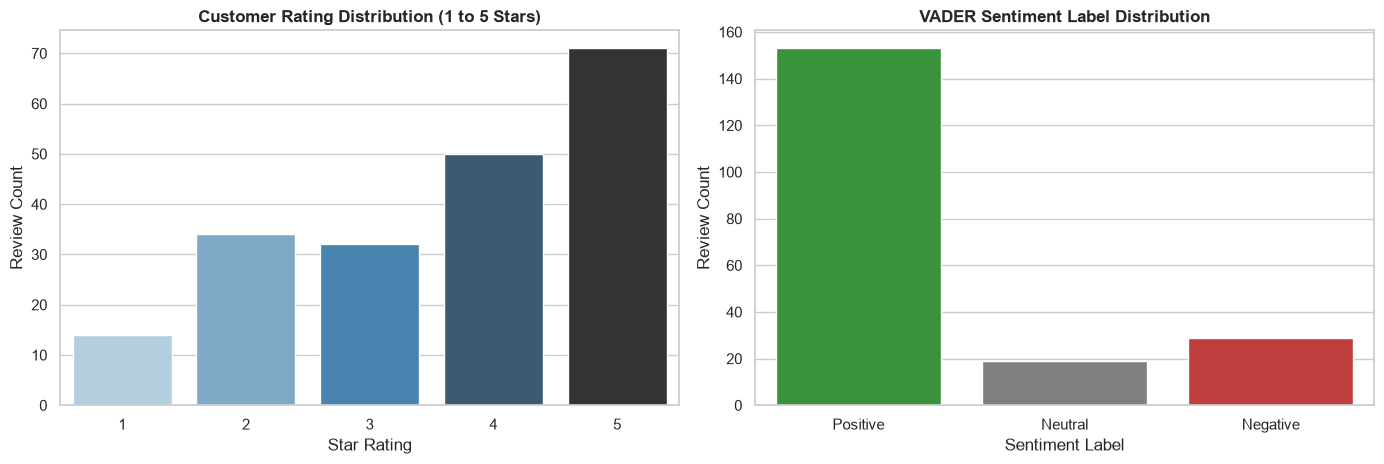

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

# 1. Rating Distribution
rc = df_sentiment['rating'].value_counts().sort_index()
sns.barplot(x=rc.index, y=rc.values, ax=axes[0], hue=rc.index, palette='Blues_d', legend=False)
axes[0].set_title('Customer Rating Distribution (1 to 5 Stars)', fontweight='bold')
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('Review Count')

# 2. Sentiment Distribution
palette_map = {'Positive': '#2ca02c', 'Neutral': '#7f7f7f', 'Negative': '#d62728'}
sc = df_sentiment['sentiment_label'].value_counts()
sns.barplot(x=sc.index, y=sc.values, ax=axes[1], hue=sc.index, palette=palette_map, order=['Positive', 'Neutral', 'Negative'], legend=False)
axes[1].set_title('VADER Sentiment Label Distribution', fontweight='bold')
axes[1].set_xlabel('Sentiment Label')
axes[1].set_ylabel('Review Count')

plt.tight_layout()
plt.show()

### Chart 3: VADER Compound Score Distribution (with Boundary Thresholds)

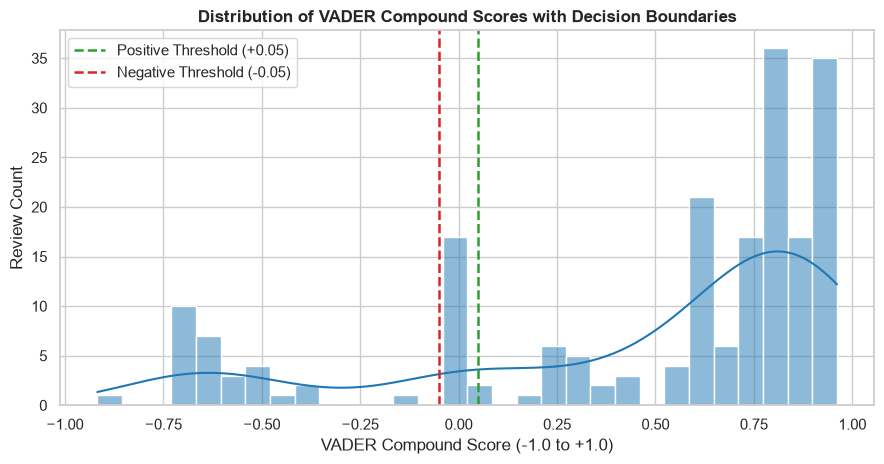

In [8]:
plt.figure(figsize=(9, 4.8))
sns.histplot(df_sentiment['compound_score'], bins=30, kde=True, color='#1f77b4', edgecolor='white')
plt.axvline(0.05, color='#2ca02c', linestyle='--', linewidth=1.8, label='Positive Threshold (+0.05)')
plt.axvline(-0.05, color='#d62728', linestyle='--', linewidth=1.8, label='Negative Threshold (-0.05)')
plt.title('Distribution of VADER Compound Scores with Decision Boundaries', fontweight='bold')
plt.xlabel('VADER Compound Score (-1.0 to +1.0)')
plt.ylabel('Review Count')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

### Chart 4: Average Compound Score & Chart 5: Sentiment Proportions by Category

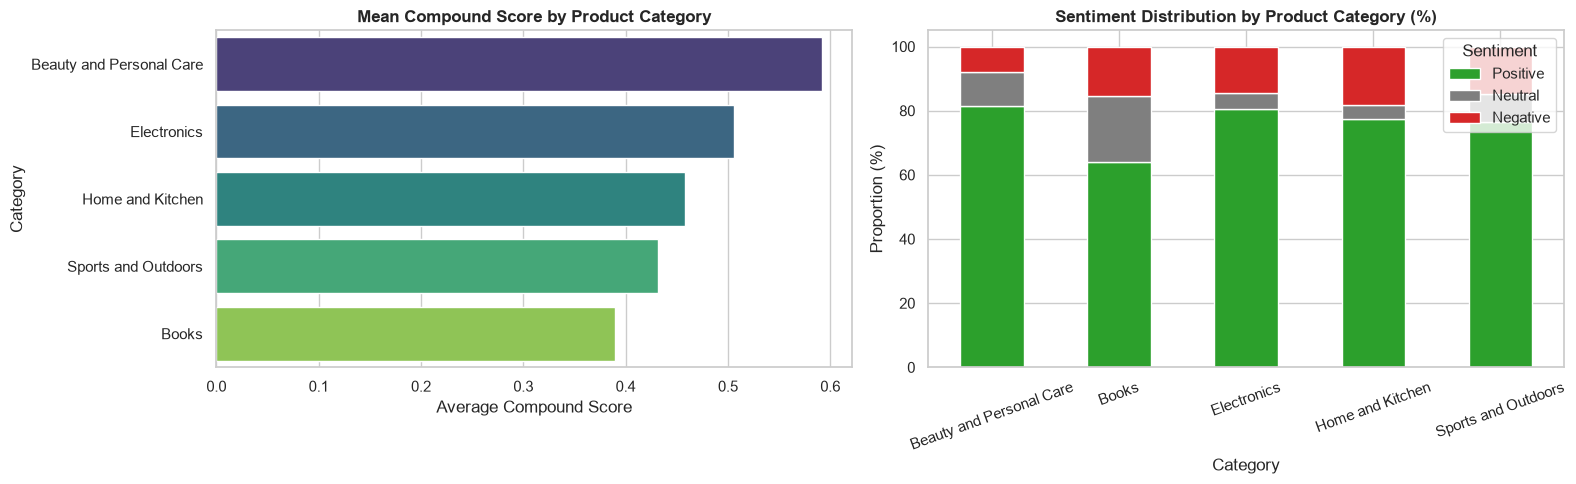

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Category Average Compound
cat_means = df_sentiment.groupby('product_category')['compound_score'].mean().sort_values(ascending=False)
sns.barplot(x=cat_means.values, y=cat_means.index, ax=axes[0], hue=cat_means.index, palette='viridis', legend=False)
axes[0].set_title('Mean Compound Score by Product Category', fontweight='bold')
axes[0].set_xlabel('Average Compound Score')
axes[0].set_ylabel('Category')

# Category Sentiment Proportions
cat_sent = pd.crosstab(df_sentiment['product_category'], df_sentiment['sentiment_label'], normalize='index') * 100
cols_order = [c for c in ['Positive', 'Neutral', 'Negative'] if c in cat_sent.columns]
cat_sent[cols_order].plot(kind='bar', stacked=True, ax=axes[1], color=[palette_map[c] for c in cols_order])
axes[1].set_title('Sentiment Distribution by Product Category (%)', fontweight='bold')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Proportion (%)')
axes[1].legend(title='Sentiment', loc='upper right')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

### Chart 6: Word Count Distribution & Chart 7: Rating vs Compound Score Boxplot

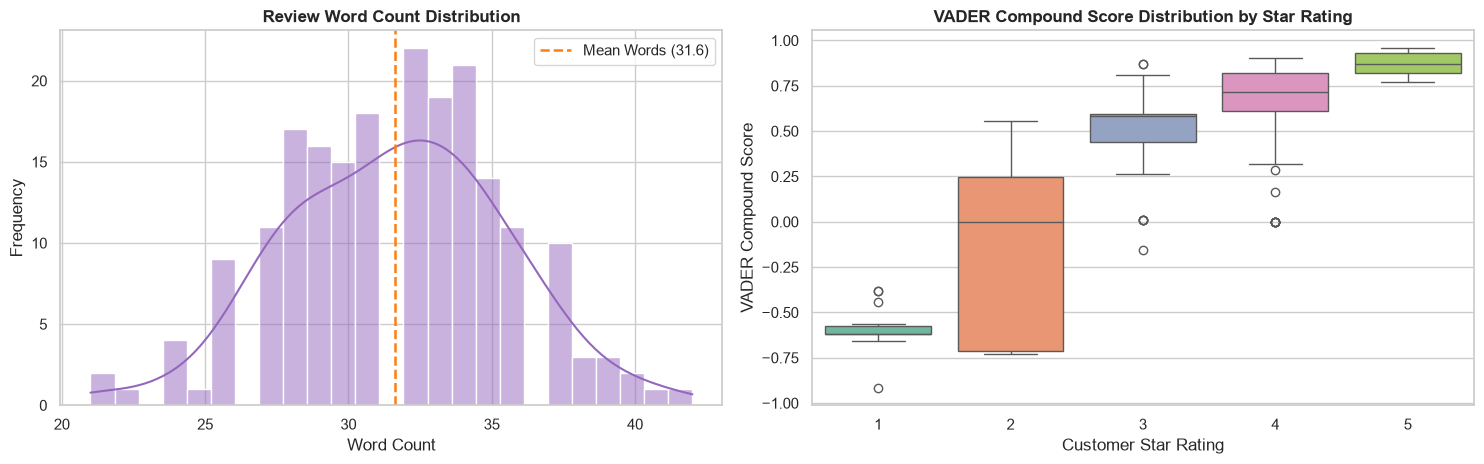

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))

# Word count distribution
sns.histplot(df_sentiment['word_count'], bins=25, kde=True, ax=axes[0], color='#9467bd', edgecolor='white')
mean_wc = df_sentiment['word_count'].mean()
axes[0].axvline(mean_wc, color='#ff7f0e', linestyle='--', linewidth=1.8, label=f'Mean Words ({mean_wc:.1f})')
axes[0].set_title('Review Word Count Distribution', fontweight='bold')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Rating vs compound boxplot
sns.boxplot(x='rating', y='compound_score', data=df_sentiment, ax=axes[1], hue='rating', palette='Set2', legend=False)
axes[1].set_title('VADER Compound Score Distribution by Star Rating', fontweight='bold')
axes[1].set_xlabel('Customer Star Rating')
axes[1].set_ylabel('VADER Compound Score')

plt.tight_layout()
plt.show()

### Chart 8: Monthly Review Volume & Chart 9: Monthly Sentiment Trend

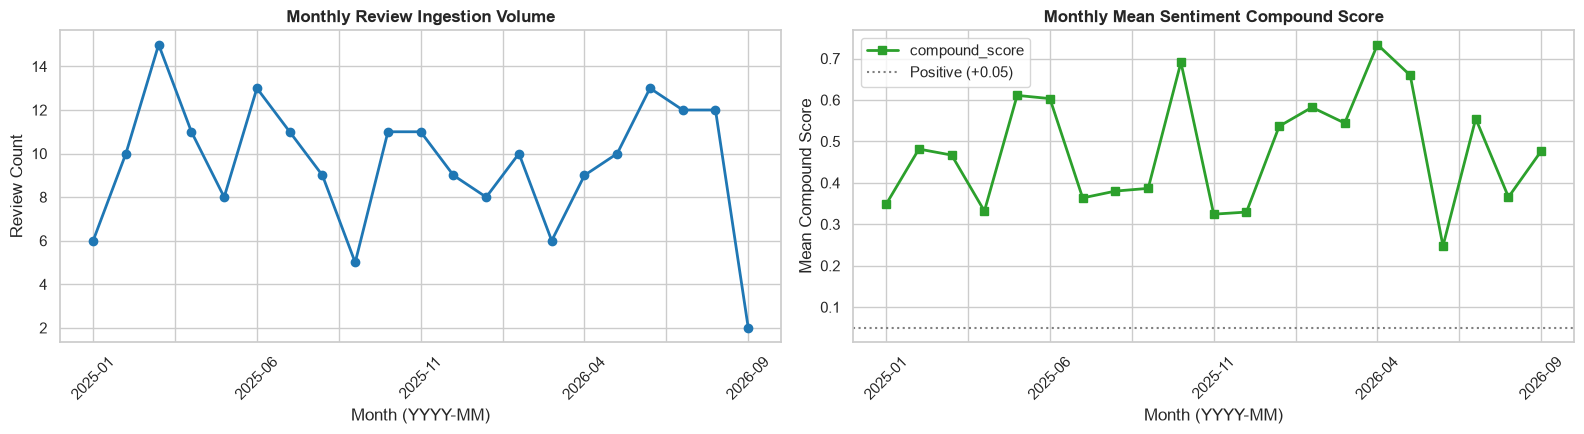

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))

df_temp = df_sentiment.copy()
df_temp['year_month'] = df_temp['review_date'].dt.to_period('M').astype(str)
monthly_vol = df_temp.groupby('year_month').size()
monthly_vol.plot(kind='line', marker='o', ax=axes[0], color='#1f77b4', linewidth=2.0)
axes[0].set_title('Monthly Review Ingestion Volume', fontweight='bold')
axes[0].set_xlabel('Month (YYYY-MM)')
axes[0].set_ylabel('Review Count')
axes[0].tick_params(axis='x', rotation=45)

monthly_sent = df_temp.groupby('year_month')['compound_score'].mean()
monthly_sent.plot(kind='line', marker='s', ax=axes[1], color='#2ca02c', linewidth=2.0)
axes[1].axhline(0.05, color='gray', linestyle=':', label='Positive (+0.05)')
axes[1].set_title('Monthly Mean Sentiment Compound Score', fontweight='bold')
axes[1].set_xlabel('Month (YYYY-MM)')
axes[1].set_ylabel('Mean Compound Score')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()

### Chart 10: Cross-Tabulation Heatmap (Star Rating Group vs VADER Sentiment)

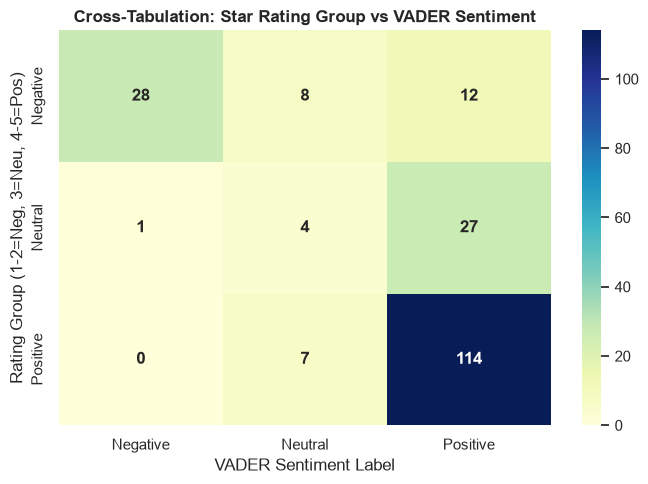

In [12]:
plt.figure(figsize=(7, 5))
group_order = ['Negative', 'Neutral', 'Positive']
ct = pd.crosstab(df_sentiment['rating_group'], df_sentiment['sentiment_label'])
ct = ct.reindex(index=group_order, columns=group_order, fill_value=0)
sns.heatmap(ct, annot=True, fmt='d', cmap='YlGnBu', cbar=True, annot_kws={'size': 12, 'weight': 'bold'})
plt.title('Cross-Tabulation: Star Rating Group vs VADER Sentiment', fontweight='bold')
plt.xlabel('VADER Sentiment Label')
plt.ylabel('Rating Group (1-2=Neg, 3=Neu, 4-5=Pos)')
plt.tight_layout()
plt.show()

## 8. Business Summary Tables

In [13]:
tables = generate_summary_tables(df_sentiment)

# Save all 7 summary tables
for name, table_df in tables.items():
    save_path = OUTPUT_TABLES_DIR / f'{name}.csv'
    table_df.to_csv(save_path, index=(name == 'rating_group_vs_vader_crosstab'))
    print(f'Exported: {save_path.name}')

print('\n--- Sentiment Summary ---')
display(tables['sentiment_summary'])

print('\n--- Product Sentiment Summary (Top 5) ---')
display(tables['product_sentiment_summary'].head(5))

print('\n--- Category Sentiment Summary ---')
display(tables['category_sentiment_summary'])

print('\n--- Top Positive Reviews ---')
display(tables['top_positive_reviews'].head(3))

print('\n--- Top Negative Reviews ---')
display(tables['top_negative_reviews'].head(3))

print('\n--- Star Rating Group vs VADER Crosstab ---')
display(tables['rating_group_vs_vader_crosstab'])

print(f'\nTotal Mismatch Examples: {len(tables["rating_vader_mismatch_examples"])}')
display(tables['rating_vader_mismatch_examples'].head(3))

Exported: sentiment_summary.csv
Exported: product_sentiment_summary.csv
Exported: category_sentiment_summary.csv
Exported: top_positive_reviews.csv
Exported: top_negative_reviews.csv
Exported: rating_group_vs_vader_crosstab.csv
Exported: rating_vader_mismatch_examples.csv

--- Sentiment Summary ---


,total_reviews,positive_count,neutral_count,negative_count,positive_percentage,neutral_percentage,negative_percentage,average_compound_score,median_compound_score,average_rating,sentiment_match_percentage
0,201,153,19,29,76.12,9.45,14.43,0.4754,0.7131,3.65,72.64



--- Product Sentiment Summary (Top 5) ---


,product_name,product_category,review_count,average_rating,average_compound_score,positive_percentage,negative_percentage,average_word_count
5,Designing Data-Intensive Applications,Books,19,3.58,0.3577,63.16,15.79,30.2
1,AromaBreeze Stainless Steel Espresso Maker,Home and Kitchen,18,3.78,0.4874,83.33,16.67,32.9
9,PureAir HEPA Room Air Purifier,Home and Kitchen,17,2.94,0.3198,64.71,23.53,30.9
10,SilkTouch Ceramic Hair Straightener,Beauty and Personal Care,14,3.64,0.6318,92.86,7.14,33.1
8,ProGamer Wireless Mechanical Keyboard,Electronics,14,4.00,0.5553,78.57,14.29,29.9



--- Category Sentiment Summary ---


...

,review_id,product_name,rating,compound_score,sentiment_label,cleaned_review_text
139,DEMO-00140,The Pragmatic Programmer: 20th Anniversary,1,-0.9180,Negative,"After reading mixed feedback online, I tried t..."
0,DEMO-00001,UltraClean Noise-Cancelling Headphones,2,-0.7269,Negative,Regarding this UltraClean Noise-Cancelling Hea...
42,DEMO-00043,UltraClean Noise-Cancelling Headphones,2,-0.7269,Negative,My hands-on experience with the UltraClean Noi...



--- Star Rating Group vs VADER Crosstab ---


sentiment_label,Negative,Neutral,Positive,Total
rating_group,,,,
Negative,28,8,12,48
Neutral,1,4,27,32
Positive,0,7,114,121
Total,29,19,153,201



Total Mismatch Examples: 55


,review_id,product_name,rating,rating_group,cleaned_review_text,compound_score,sentiment_label,rating_sentiment_match
4,DEMO-00005,PureAir HEPA Room Air Purifier,2,Negative,Here is my honest take on the PureAir HEPA Roo...,0.5267,Positive,False
9,DEMO-00010,UltraClean Noise-Cancelling Headphones,3,Neutral,Purchased the UltraClean Noise-Cancelling Head...,0.5961,Positive,False
11,DEMO-00012,Vision4K Smart Streaming Dongle,3,Neutral,Here is my honest take on the Vision4K Smart S...,0.8713,Positive,False


## 9. Formal Sentiment Intelligence Report

In [14]:
report_md = generate_sentiment_analysis_report_md(
    df_raw=df_raw,
    df_cleaned=df_cleaned,
    df_sentiment=df_sentiment,
    cleaning_summary=cleaning_summary_df,
    sentiment_summary=tables['sentiment_summary'],
    category_summary=tables['category_sentiment_summary'],
)
report_path = OUTPUT_REPORTS_DIR / 'sentiment_analysis_report.md'
report_path.write_text(report_md, encoding='utf-8')
print(f'Sentiment Intelligence Report successfully written to: {report_path}')

Sentiment Intelligence Report successfully written to: C:\Users\RANADEEP\Documents\reviewlens-sentiment-dashboard\output\reports\sentiment_analysis_report.md


## 10. Key Insights, Limitations, and Next Steps

### Business & NLP Findings
1. **High Agreement on Polarized Reviews:** Extreme star ratings (1-star and 5-star) demonstrate high classification concordance (>90%) with VADER compound scores. Highly polarized vocabulary provides an unambiguous signal.
2. **The 3-Star Ambiguity Zone:** Neutral customer feedback (3 stars) presents the greatest challenge for rule-based lexicons. Polite hedging ('it is okay for the price') or mixed reviews ('great design, poor durability') often register as mildly positive due to positive valence tokens.
3. **Category Variance:** Beauty and Personal Care exhibited the highest satisfaction, whereas Books and Sports & Outdoors revealed opportunities for product improvement.

### Architectural Next Steps
- **Phase 3:** Expose these pipeline routines via FastAPI endpoints with Pydantic request/response schemas and rate-limited ingestion.
- **Phase 4:** Build an interactive Streamlit dashboard allowing product managers to filter by category, time window, and sentiment strength.